In [1]:
import xarray as xr
import matplotlib.pyplot as plt
from cmocean import cm # for oceanography-specific colormaps
from scipy.io import loadmat
import numpy as np
import re
from xml.etree import ElementTree as ET
from matplotlib.path import Path
import pandas as pd
## cross corr and spectrum
from statsmodels.tsa.stattools import ccf
from scipy.signal import coherence, csd
from scipy.fft import fftfreq
import statsmodels.api as sm
from scipy import signal

In [2]:
ds = xr.open_dataset('../../NHCS/hincast_1980-2015/croco_avg_Y1980M01.nc', 
                     chunks = {'time':1})
ds

<xarray.Dataset> Size: 891MB
Dimensions:     (xi_rho: 602, xi_u: 601, eta_rho: 542, eta_v: 541, s_rho: 32,
                 s_w: 33, time: 1, auxil: 4)
Coordinates: (12/13)
  * xi_rho      (xi_rho) float64 5kB 1.0 2.0 3.0 4.0 ... 599.0 600.0 601.0 602.0
  * xi_u        (xi_u) float64 5kB 1.5 2.5 3.5 4.5 ... 598.5 599.5 600.5 601.5
  * eta_rho     (eta_rho) float64 4kB 1.0 2.0 3.0 4.0 ... 540.0 541.0 542.0
  * eta_v       (eta_v) float64 4kB 1.5 2.5 3.5 4.5 ... 538.5 539.5 540.5 541.5
  * s_rho       (s_rho) float64 256B -0.9844 -0.9531 ... -0.04688 -0.01562
  * s_w         (s_w) float64 264B -1.0 -0.9688 -0.9375 ... -0.0625 -0.03125 0.0
    ...          ...
    lat_rho     (eta_rho, xi_rho) float64 3MB dask.array<chunksize=(542, 602), meta=np.ndarray>
    lon_u       (eta_rho, xi_u) float64 3MB dask.array<chunksize=(542, 601), meta=np.ndarray>
    lat_u       (eta_rho, xi_u) float64 3MB dask.array<chunksize=(542, 601), meta=np.ndarray>
    lon_v       (eta_v, xi_rho) float64 3MB dask.array<chunksize=(541, 602), meta=np.ndarray>
    lat_v       (eta_v, xi_rho) float64 3MB dask.array<chunksize=(541, 602), meta=np.ndarray>
  * time        (time) float32 4B 1.339e+06
Dimensions without coordinates: auxil
Data variables: (12/54)
    spherical   |S1 1B ...
    xl          float64 8B ...
    el          float64 8B ...
    Vtransform  float64 8B ...
    sc_r        (s_rho) float64 256B dask.array<chunksize=(32,), meta=np.ndarray>
    sc_w        (s_w) float64 264B dask.array<chunksize=(33,), meta=np.ndarray>
    ...          ...
    swflux      (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    radsw       (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    shflx_rlw   (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    shflx_lat   (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    shflx_sen   (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    hel         (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
Attributes: (12/57)
    type:           ROMS restart file
    title:          Peru UW Interannual Run
    date:           
    rst_file:       croco_rst.nc
    his_file:       croco_his.nc
    avg_file:       croco_avg.nc
    ...             ...
    gamma2_expl:    Slipperiness parameter
    x_sponge:       0.0
    v_sponge:       0.0
    sponge_expl:    Sponge parameters : extent (m) & viscosity (m2.s-1)
    SRCS:           main.F step.F read_inp.F timers_roms.F init_scalars.F ini...
    CPP-options:    REGIONAL PERU_UW MPI OBC_WEST OBC_NORTH OBC_SOUTH BIOLOGY...

In [3]:
print(ds.mask_rho.shape)
mask_rho = ds.mask_rho.values 
mask_nan = np.where(mask_rho, 1, np.nan)
expanded_mask = np.tile(mask_nan[np.newaxis, :, :], (432, 1, 1))

(542, 602)


In [4]:
SSH = loadmat("../../NHCS/Processed/SST_SSH.mat")

time = pd.date_range(start="1980-01",end="2016-01",freq='M')
ds_SSH = xr.Dataset(
    data_vars={
        'SSH':(("time", "lat","lon"), SSH['SSH'].transpose(2, 1, 0)*expanded_mask),
        
    },
    coords = {
        'lon':ds.lon_rho.compute().values[0,:],
        'lat':ds.lat_rho.compute().values[:,0],
        'time':time
}
)
ds_SSH

/tmp/ipykernel_933825/1752186948.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  time = pd.date_range(start="1980-01",end="2016-01",freq='M')


<xarray.Dataset> Size: 1GB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    SSH      (time, lat, lon) float64 1GB 0.212 0.212 0.2117 ... nan nan nan

In [20]:
UGEO = loadmat("../../NHCS/Processed/CUTI_components.mat")
UGEO

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Fri Oct 24 15:48:03 2025',
 '__version__': '1.0',
 '__globals__': [],
 'UEK': array([[[ 0.0978836 ,  0.18741026, -0.45390522, ..., -0.29767859,
          -0.08064434, -0.1136856 ],
         [ 0.09780401,  0.19106862, -0.45497172, ..., -0.29379974,
          -0.08408418, -0.11264402],
         [ 0.09767365,  0.19472327, -0.45558183, ..., -0.28958518,
          -0.08707098, -0.11229189],
         ...,
         [-1.04143563, -1.179635  , -2.03420194, ...,  1.16063094,
           0.16765576, -2.25044763],
         [-1.04580906, -1.20372665, -2.05896632, ...,  1.12175662,
           0.13341219, -2.31331741],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan]],
 
        [[ 0.10202834,  0.19512215, -0.45187811, ..., -0.29022753,
          -0.0822974 , -0.11456014],
         [ 0.10335079,  0.19769727, -0.45246358, ..., -0.28642312,
          -0.08556651, -0.11334352],
     

## Functions 

In [5]:
## kml to struct
import re
from xml.etree import ElementTree as ET
import numpy as np

def kml2struct(kml_file):
    """
    Import a .kml file as a list of dictionary structures with fields:
    Geometry, Name, Description, Lon, Lat, and BoundingBox.
    """
    # Read the KML file
    try:
        with open(kml_file, 'r', encoding='utf-8') as file:
            txt = file.read()
    except Exception as e:
        raise FileNotFoundError(f"Unable to open file {kml_file}: {e}")

    # Regular expression to match Placemark tags
    expr = r"<Placemark.+?>.+?</Placemark>"
    object_strings = re.findall(expr, txt, re.DOTALL)
    
    kml_struct = []

    for obj_str in object_strings:
        # Extract Name
        name_match = re.search(r"<name.*?>(.*?)</name>", obj_str, re.DOTALL)
        name = name_match.group(1).strip() if name_match else "undefined"

        # Extract Description
        desc_match = re.search(r"<description.*?>(.*?)</description>", obj_str, re.DOTALL)
        desc = desc_match.group(1).strip() if desc_match else ""

        # Determine Geometry Type
        geometry = ""
        if "<Point" in obj_str:
            geometry = "Point"
        elif "<LineString" in obj_str:
            geometry = "Line"
        elif "<Polygon" in obj_str:
            geometry = "Polygon"

        # Extract Coordinates
        coord_match = re.search(r"<coordinates.*?>(.*?)</coordinates>", obj_str, re.DOTALL)
        if not coord_match:
            continue  # Skip if no coordinates are found
        coord_str = coord_match.group(1).strip()
        coord_list = np.array([list(map(float, coord.split(','))) for coord in coord_str.split()])

        # Separate Lon, Lat, and handle Polygons
        lon = coord_list[:, 0]
        lat = coord_list[:, 1]
        if geometry == "Polygon":
            # Close the polygon by appending NaN
            lon = np.append(lon, np.nan)
            lat = np.append(lat, np.nan)

        # Create BoundingBox
        bounding_box = [[lon.min(), lat.min()], [lon.max(), lat.max()]]

        # Append to kml_struct
        kml_struct.append({
            "Geometry": geometry,
            "Name": name,
            "Description": desc,
            "Lon": lon,
            "Lat": lat,
            "BoundingBox": bounding_box
        })

    return kml_struct

In [6]:
# Load the KML file to get the polygon boundary
arch_kml_zona1 = "../../NHCS/hindcast/CROCO_BioEBUS_1990-2010/indices/BK111km.kml"
R1 = kml2struct(arch_kml_zona1)

# Extract Lon and Lat from the first polygon
lonb1 = R1[0]["Lon"]
latb1 = R1[0]["Lat"]

In [7]:
from matplotlib.path import Path
LON, LAT = np.meshgrid(ds_SSH.lon,ds_SSH.lat)
# Create a path from the polygon coordinates
polygon = Path(np.column_stack((lonb1, latb1)))

# Flatten the LON and LAT to create coordinate pairs
lonlat_points = np.column_stack((LON.ravel(), LAT.ravel()))

# Check which points are inside the polygon
mask = polygon.contains_points(lonlat_points).reshape(LON.shape)

# Convert the mask to NaN for the outshore region
inshore_mask = np.where(mask, 1, np.nan)

In [8]:
### Spectrum
def normalize(data):
    return (data - data.min()) / (data.max() - data.min())

def zscore(x):
    return (x - x.mean()) / x.std()
    
def analyze_correlation_and_spectrum(df, x_col, y_col, lags=int, nperseg=int, xlim=500):
    """
    Plot time series, autocorrelation, cross-correlation, coherence, phase, and PSD
    between two signals in a DataFrame.

    Parameters:
        df (pd.DataFrame): DataFrame containing time series data
        x_col (str): Name of the X (reference) column
        y_col (str): Name of the Y (target) column
        lags (int): Number of lags for correlation functions
        nperseg (int): Segment length for spectral analysis
        xlim (int): Optional limit for time series plot
    """
    
    x = df[x_col]
    y = df[y_col]

    # Plot time series
    plt.figure(figsize=(12, 5))
    plt.plot(normalize(x), label=x_col, alpha=0.7)
    plt.plot(normalize(y), label=y_col, alpha=0.7)
    plt.title(f"Time Series Plot: {y_col} vs {x_col}")
    # plt.xlim(0, xlim)
    plt.legend()
    plt.grid(True)
    plt.show()

    # Autocorrelation of x
    autocorr = sm.tsa.acf(zscore(x), nlags=lags)

    # Cross-correlations
    crosscorr_xy = sm.tsa.ccf(zscore(y), zscore(x), adjusted=False)[:lags]
    crosscorr_yx = sm.tsa.ccf(zscore(x), zscore(y), adjusted=False)[:lags]

    # top lags
    cross_corr = np.concatenate([crosscorr_xy, crosscorr_yx])
    lags_array = np.concatenate([-np.arange(lags-1, -1, -1), np.arange(1, lags)])

        #top 3 peaks
    top_idxs = np.argsort(np.abs(cross_corr))[-3:][::-1]
    print("\nTop 3 cross-correlation peaks:")
    for idx in top_idxs:
        print(f"r = {cross_corr[idx]:.3f}  |  lag = {lags_array[idx]}")
        
    # Spectral analysis
    fxx, Pxx = signal.welch(x, nperseg=nperseg)
    fyy, Pyy = signal.welch(y, nperseg=nperseg)
    fxy, Pxy = signal.csd(x, y, nperseg=nperseg)
    fcoh, Kxy = signal.coherence(x, y, nperseg=nperseg)
    
    phase = np.angle(Pxy, deg=True)
    # if y_col == 'Y4':
    #     phase= np.where(phase < 0, phase + 360, phase)
            


    # Plot
    fig, axs = plt.subplots(2, 2, figsize=(9, 7.5))

    # Cross-correlation plot
    axs[0, 0].plot(np.arange(0, lags + 1), autocorr, 'b', label=r'$\rho_{xx}$')
    axs[0, 0].plot(-np.arange(0, lags + 1), autocorr, 'b')
    axs[0, 0].plot(np.arange(0, lags), crosscorr_xy, 'r', label=fr'$\rho_{{{y_col},{x_col}}}$')
    axs[0, 0].plot(-np.arange(0, lags), crosscorr_yx, 'r')
    axs[0, 0].set_title(f'Cross-correlation between {x_col} and {y_col}')
    axs[0, 0].set_xlabel('Time lag [steps]')
    axs[0, 0].set_ylabel('Correlation')
    axs[0, 0].grid(True)
    axs[0, 0].legend()

    # Coherence using signal.coherence
    axs[0, 1].semilogx(fcoh, Kxy)
    axs[0, 1].set_title(f'Coherence ({x_col} vs {y_col})')
    axs[0, 1].set_xlabel('Frequency [1/time step]')
    axs[0, 1].set_ylabel('Coherence')
    axs[0, 1].grid(True, which='both', linestyle='--', linewidth=0.5)
    axs[0, 1].set_ylim(0, 1)

    # Phase 
    axs[1, 0].semilogx(fxx, phase[:len(fxx)])
    axs[1, 0].set_title(f'Phase ({x_col} leads {y_col})')
    axs[1, 0].set_xlabel('Frequency [1/time step]')
    axs[1, 0].set_ylabel('Phase [degrees]')
    axs[1, 0].grid(True, which='both', linestyle='--', linewidth=0.5)
    # if y_col == 'Y4':
    #     axs[1, 0].set_ylim(0, 350)

    # Power Spectral Density
    axs[1, 1].semilogx(fxx, Pxx, label=x_col)
    axs[1, 1].semilogx(fyy, Pyy, label=y_col)
    axs[1, 1].set_title('Power Spectral Density')
    axs[1, 1].set_xlabel('Frequency [1/time step]')
    axs[1, 1].set_ylabel('Power')
    axs[1, 1].legend()
    axs[1, 1].grid(True)

    plt.tight_layout()
    plt.show()

## CUTI components

In [9]:
CUTI_data = loadmat("../../NHCS/Processed/CUTI.mat")

MLD = loadmat("../../NHCS/Processed/WMLD_MLD.mat")


In [10]:
##----Ekman 
Ekman_data = loadmat("../../NHCS/Processed/EKMAN_components.mat")
Ek_pump = Ekman_data['EK_pump']
# ## Ekman transport
Ek_tr = Ekman_data['UEK']*-1

In [21]:
UGEO = UGEO['UGEO']
UGEO

array([[[-0.00000000e+00, -0.00000000e+00, -0.00000000e+00, ...,
         -0.00000000e+00, -0.00000000e+00, -0.00000000e+00],
        [-6.52471110e-02, -1.37675516e-02, -1.82159152e-02, ...,
         -9.86302365e-03, -5.31817134e-03, -2.40862209e-04],
        [-6.76662028e-02, -2.18167510e-02, -2.72663105e-02, ...,
         -7.41939479e-03, -7.66004669e-03, -3.32949543e-03],
        ...,
        [ 1.09555982e-02,  2.19447613e-01,  2.00437084e-01, ...,
          8.86582136e-02,  6.10277131e-02,  1.60189256e-01],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan]],

       [[-1.18405451e-05, -1.46822749e-05, -2.84173097e-06, ...,
         -1.82344393e-05, -1.23141672e-05, -5.68346195e-06],
        [-6.52459264e-02, -1.37680257e-02, -1.82159152e-02, ...,
         -9.86160059e-03, -5.31769730e

In [22]:
CUTI_ds = xr.Dataset(
    data_vars={
        'CUTI': (("time", "lat","lon"), CUTI_data['CUTI'].transpose(2, 1, 0) *-1),
        'Ekman_transport':(("time", "lat","lon"), Ek_tr.transpose(2, 1, 0)),
        'UGEO':(("time", "lat","lon"), UGEO.transpose(2, 1, 0)),

    },
    coords = {
        'lon':ds.lon_rho.compute().values[0,:],
        'lat':ds.lat_rho.compute().values[:,0],
        'time':time
}
)

mask_rho = ds.mask_rho.values 
mask_nan = np.where(mask_rho, 1, np.nan)

CUTI_ds = CUTI_ds * inshore_mask *mask_nan

In [23]:
CUTI_ds

<xarray.Dataset> Size: 3GB
Dimensions:          (lon: 602, lat: 542, time: 432)
Coordinates:
  * lon              (lon) float64 5kB -119.0 -118.9 -118.8 ... -68.95 -68.87
  * lat              (lat) float64 4kB -33.0 -32.93 -32.86 ... 9.869 9.951 10.03
  * time             (time) datetime64[ns] 3kB 1980-01-31 ... 2015-12-31
Data variables:
    CUTI             (time, lat, lon) float64 1GB nan nan nan ... nan nan nan
    Ekman_transport  (time, lat, lon) float64 1GB nan nan nan ... nan nan nan
    UGEO             (time, lat, lon) float64 1GB nan nan nan ... nan nan nan

In [12]:
MLD_ds = xr.Dataset(
    data_vars={
        'MLD': (("time", "lat","lon"), MLD['MLD'].transpose(2, 1, 0)*expanded_mask* inshore_mask),
    },
    coords = {
        'lon':ds.lon_rho.compute().values[0,:],
        'lat':ds.lat_rho.compute().values[:,0],
        'time':time
}
)

MLD_ds

<xarray.Dataset> Size: 1GB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    MLD      (time, lat, lon) float64 1GB nan nan nan nan ... nan nan nan nan

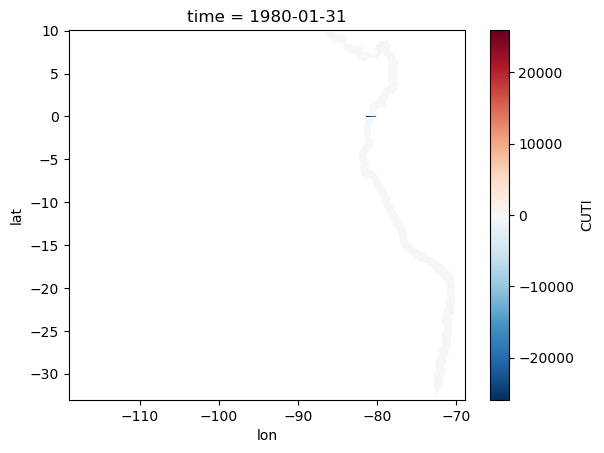

In [13]:
CUTI_ds.isel(time=0).CUTI.plot()

In [14]:
def seasonality(data):
    
    season = data.groupby('time.month').mean(dim='time')
    return season

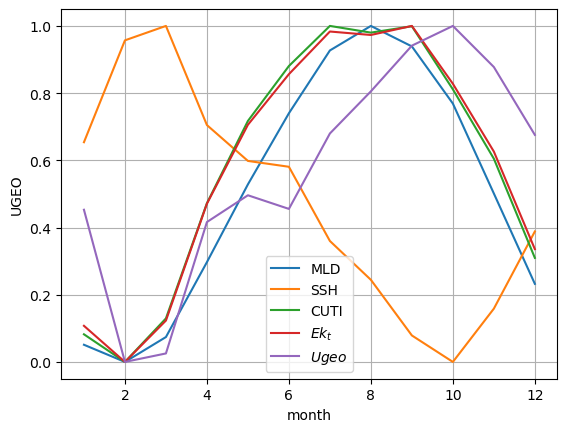

In [24]:
normalize(seasonality(MLD_ds.MLD).sel(
    lat=slice(-16,-5)).mean(dim=('lon','lat'))).plot(label='MLD')

normalize(seasonality(ds_SSH * inshore_mask *mask_nan).SSH.sel(
    lat=slice(-16,-5)).mean(dim=('lon','lat'))).plot(label='SSH')

normalize(seasonality(CUTI_ds.CUTI).sel(
    lat=slice(-16,-5)).mean(dim=('lon','lat'))).plot(label='CUTI')

normalize(seasonality(CUTI_ds.Ekman_transport).sel(
    lat=slice(-16,-5)).mean(dim=('lon','lat'))).plot(label='$Ek_t$')

normalize(seasonality(CUTI_ds.UGEO).sel(
    lat=slice(-16,-5)).mean(dim=('lon','lat'))).plot(label='$Ugeo$')

plt.legend()
plt.grid()

In [27]:
print(seasonality(CUTI_ds.UGEO).sel(
    lat=slice(-16,-5)).mean(dim=('lon','lat')))

print(seasonality(CUTI_ds.Ekman_transport).sel(
    lat=slice(-16,-5)).mean(dim=('lon','lat')))

<xarray.DataArray 'UGEO' (month: 12)> Size: 96B
array([-0.23057676, -0.28258539, -0.27968676, -0.23477816, -0.22562476,
       -0.23028614, -0.20450756, -0.19010358, -0.17448735, -0.16774508,
       -0.18179389, -0.20498741])
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
<xarray.DataArray 'Ekman_transport' (month: 12)> Size: 96B
array([1.38733304, 1.20344164, 1.41408155, 2.00913477, 2.41118448,
       2.66883451, 2.88603437, 2.86844452, 2.9145288 , 2.61997457,
       2.2746269 , 1.77785643])
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12


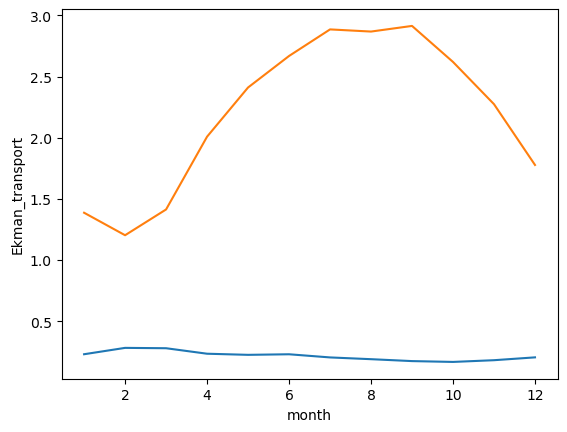

In [39]:
# seasonality(CUTI_ds.UGEO*-1 + CUTI_ds.Ekman_transport).sel(
#     lat=slice(-16,-5)).mean(dim=('lon','lat')).plot()

seasonality(CUTI_ds.UGEO*-1).sel(
    lat=slice(-16,-5)).mean(dim=('lon','lat')).plot()

seasonality(CUTI_ds.Ekman_transport).sel(
    lat=slice(-16,-5)).mean(dim=('lon','lat')).plot()

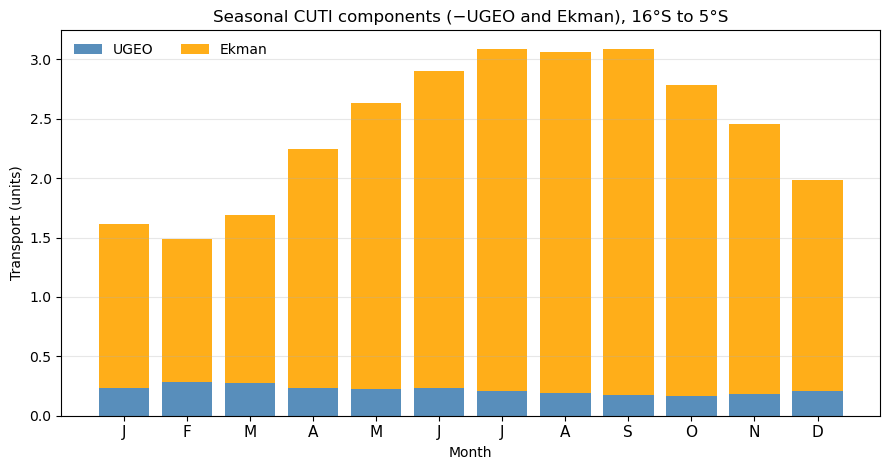

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

# Helper: ensure month coordinate is 1..12
def to_month_1_12(da):
    if 'month' in da.coords:
        m = da['month'].values
        if np.min(m) == 0 and np.max(m) == 11:
            da = da.assign_coords(month=(('month',), m + 1))
        return da
    if 'time' in da.coords:
        return (da.assign_coords(month=da['time'].dt.month)
                  .swap_dims({'time': 'month'})
                  .groupby('month').mean())
    raise ValueError("DataArray needs a 'month' or 'time' coordinate")

months_labels = ['J','F','M','A','M','J','J','A','S','O','N','D']
full_months = np.arange(1, 13)

# Build the two series
UGEO = seasonality(CUTI_ds.UGEO * -1).sel(lat=slice(-16, -5)).mean(dim=('lon','lat'))
EKMN = seasonality(CUTI_ds.Ekman_transport).sel(lat=slice(-16, -5)).mean(dim=('lon','lat'))

UGEO = to_month_1_12(UGEO).reindex(month=full_months)
EKMN = to_month_1_12(EKMN).reindex(month=full_months)

# Convert to numpy 1D
u = UGEO.values
e = EKMN.values

# Stacked bar plot
x = full_months
width = 0.8

fig, ax = plt.subplots(figsize=(9, 4.8))

bars1 = ax.bar(x, u, width=width, label='UGEO', color='steelblue', alpha=0.9)
bars2 = ax.bar(x, e, width=width, bottom=u, label='Ekman', color='orange', alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(months_labels, fontsize=11)
ax.set_xlabel('Month')
ax.set_ylabel('Transport (units)')
ax.set_title('Seasonal CUTI components (−UGEO and Ekman), 16°S to 5°S')
ax.grid(axis='y', alpha=0.3)
ax.legend(frameon=False, ncol=2, loc='upper left')

plt.tight_layout()
plt.show()

Month  1: UGEO   14.3% | Ekman   85.7% | Total=1.62
Month  2: UGEO   19.0% | Ekman   81.0% | Total=1.49
Month  3: UGEO   16.5% | Ekman   83.5% | Total=1.69
Month  4: UGEO   10.5% | Ekman   89.5% | Total=2.24
Month  5: UGEO    8.6% | Ekman   91.4% | Total=2.64
Month  6: UGEO    7.9% | Ekman   92.1% | Total=2.9
Month  7: UGEO    6.6% | Ekman   93.4% | Total=3.09
Month  8: UGEO    6.2% | Ekman   93.8% | Total=3.06
Month  9: UGEO    5.6% | Ekman   94.4% | Total=3.09
Month 10: UGEO    6.0% | Ekman   94.0% | Total=2.79
Month 11: UGEO    7.4% | Ekman   92.6% | Total=2.46
Month 12: UGEO   10.3% | Ekman   89.7% | Total=1.98


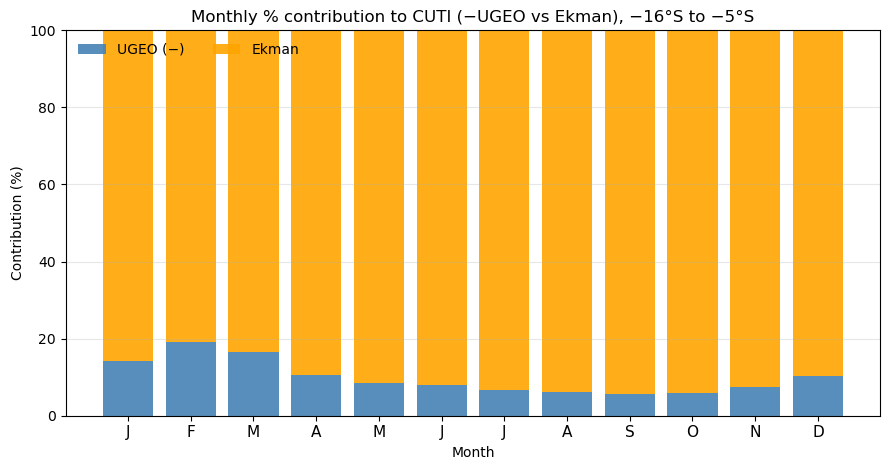

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Build monthly series (as before) and align months
def to_month_1_12(da):
    if 'month' in da.coords:
        m = da['month'].values
        if np.min(m) == 0 and np.max(m) == 11:
            da = da.assign_coords(month=(('month',), m + 1))
        return da
    if 'time' in da.coords:
        return (da.assign_coords(month=da['time'].dt.month)
                  .swap_dims({'time': 'month'})
                  .groupby('month').mean())
    raise ValueError("DataArray needs a 'month' or 'time' coordinate")

months_labels = ['J','F','M','A','M','J','J','A','S','O','N','D']
full_months = np.arange(1, 13)

UGEO = seasonality(CUTI_ds.UGEO * -1).sel(lat=slice(-16, -5)).mean(dim=('lon','lat'))
EKMN = seasonality(CUTI_ds.Ekman_transport).sel(lat=slice(-16, -5)).mean(dim=('lon','lat'))

UGEO = to_month_1_12(UGEO).reindex(month=full_months)
EKMN = to_month_1_12(EKMN).reindex(month=full_months)

u = UGEO.values
e = EKMN.values

# 2) Compute total and percentage contributions
total = u + e
eps = 1e-12  # to avoid division by zero
pct_u = 100 * u / np.where(np.abs(total) < eps, np.nan, total)
pct_e = 100 * e / np.where(np.abs(total) < eps, np.nan, total)

# Optional: handle months with zero/near-zero total (set to 0 instead of NaN)
pct_u = np.where(np.isnan(pct_u), 0.0, pct_u)
pct_e = np.where(np.isnan(pct_e), 0.0, pct_e)

# 3) Print a quick table
for m, pu, pe, tt in zip(full_months, pct_u, pct_e, total):
    print(f"Month {m:2d}: UGEO {pu:6.1f}% | Ekman {pe:6.1f}% | Total={tt:.3g}")

# 4) Plot stacked percent bar chart (100% stacked)
fig, ax = plt.subplots(figsize=(9, 4.8))
x = full_months
width = 0.8

# Split positive/negative totals if you prefer sign-aware; here we show simple 100% stack
ax.bar(x, pct_u, width=width, label='UGEO (−)', color='steelblue', alpha=0.9)
ax.bar(x, pct_e, width=width, bottom=pct_u, label='Ekman', color='orange', alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(months_labels, fontsize=11)
ax.set_xlabel('Month')
ax.set_ylabel('Contribution (%)')
ax.set_title('Monthly % contribution to CUTI (UGEO vs Ekman), 16°S to 5°S')
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)
ax.legend(frameon=False, ncol=2, loc='upper left')

plt.tight_layout()
plt.show()

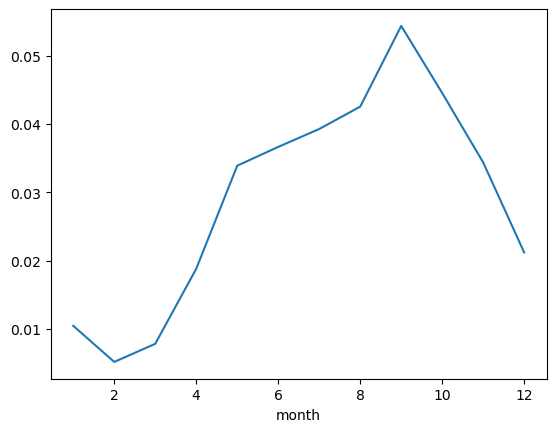

In [16]:
seasonality(((
    ds_SSH - ds_SSH.shift(lat=-1)).SSH * MLD_ds.MLD)).sel(lat=slice(-16,-5)).mean(dim=('lon','lat')).plot()